### 1-IMPORTING LIBRARIES

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional (for better visuals)
import seaborn as sns
sns.set(style="whitegrid")

### 2-LOADING DATA

In [8]:
# Load datasets
import pandas as pd

opportunity = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\Opportunity.csv")
brokerage   = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\brokerage.csv")
fees        = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\fees.csv")
invoice     = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\invoice.csv")
meeting     = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\meeting.csv")
budget      = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\Individual Budgets.csv")

### 3-DATA UNDERSTANDING

In [9]:
# Check data
opportunity.head()
brokerage.head()

# Info
opportunity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   opportunity_name   49 non-null     object
 1   opportunity_id     49 non-null     object
 2   Account Exe Id     49 non-null     int64 
 3   Account Executive  49 non-null     object
 4   premium_amount     49 non-null     int64 
 5   revenue_amount     49 non-null     int64 
 6   closing_date       49 non-null     object
 7   stage              49 non-null     object
 8   branch             49 non-null     object
 9   specialty          49 non-null     object
 10  product_group      49 non-null     object
 11  product_sub_group  49 non-null     object
 12  risk_details       49 non-null     object
dtypes: int64(3), object(10)
memory usage: 5.1+ KB


### 4-DATA CLEANING

In [12]:
import pandas as pd

# Remove exact duplicates
brokerage = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\brokerage.csv")
fees      = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\fees.csv")

brokerage.drop_duplicates(inplace=True)
fees.drop_duplicates(inplace=True)

# Fill missing values
brokerage.fillna(0, inplace=True)
fees.fillna(0, inplace=True)

# Load CSVs with date parsing
opportunity = pd.read_csv(
    r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\Opportunity.csv",
    parse_dates=['closing_date'],
    dayfirst=True
)

invoice = pd.read_csv(
    r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\invoice.csv",
    parse_dates=['invoice_date'],
    dayfirst=True
)

meeting = pd.read_csv(
    r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\meeting.csv",
    parse_dates=['meeting_date'],
    dayfirst=True
)

budget = pd.read_csv(
    r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\Individual Budgets.csv"
)

### 5-CREATED REVENUE DATA

In [30]:
import pandas as pd

# Load CSVs
brokerage = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\brokerage.csv")
fees      = pd.read_csv(r"C:\Users\hp\OneDrive\Documents\GitHub\Insurance-Business-Analytics-Dashboard\01_Raw_Data\fees.csv")

# Normalize column names (strip spaces, lowercase)
brokerage.columns = brokerage.columns.str.strip().str.lower()
fees.columns      = fees.columns.str.strip().str.lower()

# Rename executive columns to a common name
brokerage = brokerage.rename(columns={'exe name': 'account executive'})
fees      = fees.rename(columns={'account executive': 'account executive'})

# Combine Brokerage + Fees
revenue_data = pd.concat([
    brokerage[['account executive', 'amount']],
    fees[['account executive', 'amount']]
])

# Summarize total revenue per executive
revenue_summary = (
    revenue_data.groupby('account executive')['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'Total Revenue'})
)

print(revenue_summary)

   account executive  Total Revenue
0     Abhinav Shivam     1129184.87
1      Animesh Rawat     7061653.32
2            Gilbert      386738.25
3               Juli      300132.44
4         Ketan Jain     1140987.30
5          Kumar Jha      130049.50
6      Manish Sharma       66285.43
7               Mark     5125375.55
8     Nishant Sharma      396480.00
9         Raju Kumar     1373838.41
10    Shivani Sharma      924856.60
11       Vididt Saha     1604380.24
12             Vinay    15441750.10


### 6 - TARGET DATA

In [34]:
import pandas as pd

# Drop completely empty rows first
budget = budget.dropna(how='all')

# Create target column
budget['Target'] = (
    budget['New Budget'] +
    budget['Cross sell bugdet'] +
    budget['Renewal Budget']
)

# Build target_data safely
target_data = budget[['Employee Name', 'Target']].copy()

# Rename column
target_data.rename(columns={'Employee Name': 'Account Executive'}, inplace=True)

# Drop rows where Account Executive is NaN
target_data = target_data.dropna(subset=['Account Executive'])

print(target_data)

  Account Executive      Target
0             Vinay  14538092.0
1    Abhinav Shivam   1547902.0
2     Animesh Rawat  13656223.0
3           Gilbert   2510000.0
4              Juli   5500000.0
5         Kumar Jha   2813707.0
6        Ketan Jain   2250000.0
7     Manish Sharma   2850000.0
8              Mark    347547.0
9        Vidit Shah   6062888.0


### 7-MERGE DATA

In [36]:
import pandas as pd

# Ensure consistent column names
revenue_summary.rename(columns={'account executive': 'Account Executive'}, inplace=True)
target_data.rename(columns={'account executive': 'Account Executive'}, inplace=True)

# Merge revenue + target
performance = pd.merge(revenue_summary, target_data, on='Account Executive', how='left')

# Achievement %
performance['Achievement %'] = performance['Total Revenue'] / performance['Target']

print(performance.head())

  Account Executive  Total Revenue      Target  Achievement %
0    Abhinav Shivam     1129184.87   1547902.0       0.729494
1     Animesh Rawat     7061653.32  13656223.0       0.517101
2           Gilbert      386738.25   2510000.0       0.154079
3              Juli      300132.44   5500000.0       0.054570
4        Ketan Jain     1140987.30   2250000.0       0.507105


### 8-KPI CALCULATIONS

In [38]:
# Total Revenue
total_revenue = revenue_data['amount'].sum()

# Total Opportunities
total_opportunities = opportunity['opportunity_id'].count()

# Conversion Rate
closed = opportunity[opportunity['stage'] == 'Negotiate'].shape[0]
conversion_rate = closed / total_opportunities

print("Total Revenue:", total_revenue)
print("Conversion Rate:", conversion_rate)

Total Revenue: 35081712.01
Conversion Rate: 0.10204081632653061


### 9-VISUALIZATIONS

#### Target vs Achievement

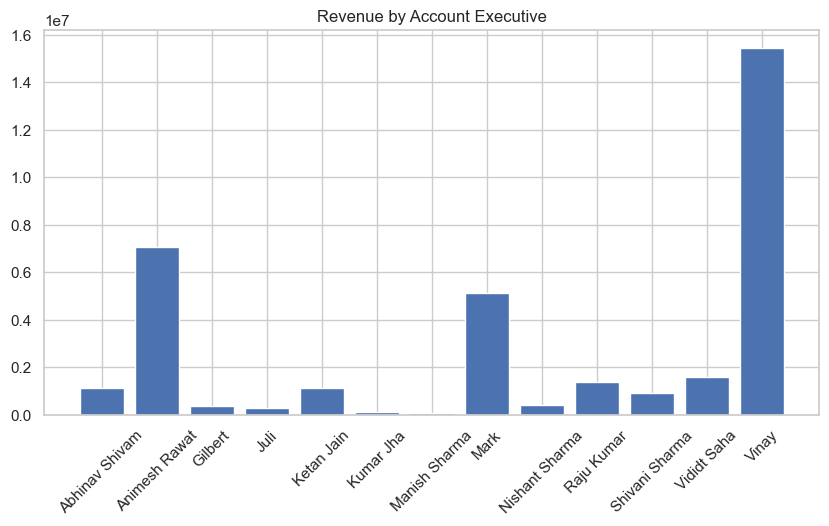

In [39]:
plt.figure(figsize=(10,5))
plt.bar(performance['Account Executive'], performance['Total Revenue'])
plt.xticks(rotation=45)
plt.title("Revenue by Account Executive")
plt.show()

#### Pipeline Analysis

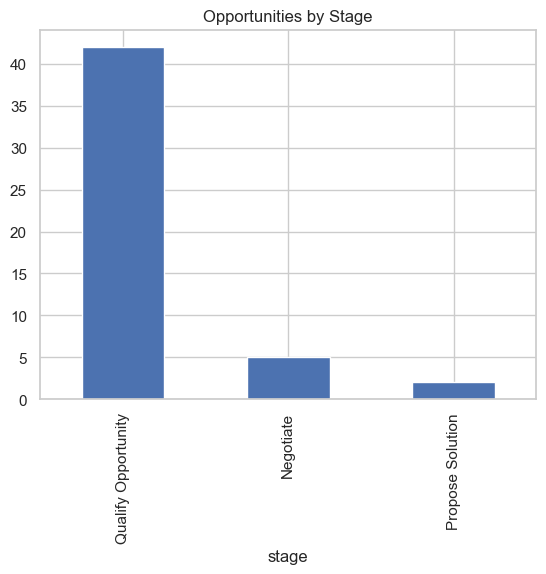

In [40]:
pipeline = opportunity['stage'].value_counts()

pipeline.plot(kind='bar')
plt.title("Opportunities by Stage")
plt.show()

#### Top Opportunities

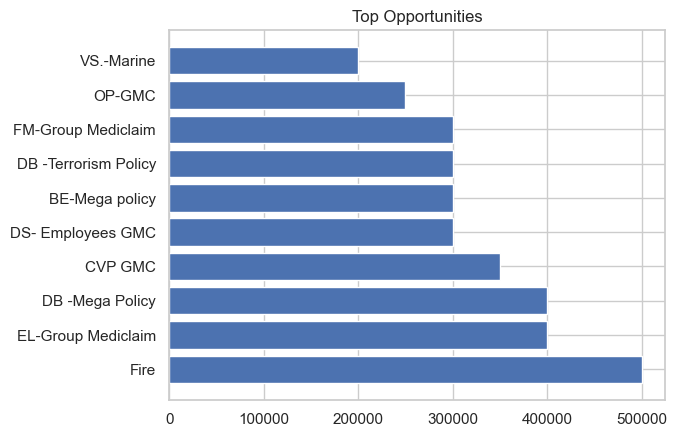

In [41]:
top_opps = opportunity.sort_values(by='revenue_amount', ascending=False).head(10)

plt.barh(top_opps['opportunity_name'], top_opps['revenue_amount'])
plt.title("Top Opportunities")
plt.show()

### 10-INSIGHTS

In [42]:
print("Key Insights:")
print("- Majority opportunities are in Qualify stage")
print("- Conversion rate is low")
print("- Revenue is concentrated among few executives")

Key Insights:
- Majority opportunities are in Qualify stage
- Conversion rate is low
- Revenue is concentrated among few executives
